In [36]:
# ROME Structural Analysis - Simplified
# Focus: Essential graphs for ROME edit detection

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === CONFIG ===
JSON_FILE = None  # Auto-select latest, or set specific path
SELECTED_CASE_ID = 0

# Load data
analysis_dir = Path("./analysis_out")
if JSON_FILE is None:
    candidates = sorted(analysis_dir.glob("*.jsxn"), key=lambda p: p.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No .jsxn files found in {analysis_dir}")
    JSON_FILE = str(candidates[-1])

with open(JSON_FILE) as f:
    data = json.load(f)

target_layer = data['metadata']['target_layer']
case = data['tests'][SELECTED_CASE_ID]

print(f"File: {JSON_FILE}")
print(f"Model: {data['metadata']['model']} | Target Layer: {target_layer}")
print(f"Case: {case['subject']} | ROME: {'OK' if case.get('rome', {}).get('success') else 'FAIL'}")

File: analysis_out/rome_structural_gpt2-large_2026-02-04_00-14-49.jsxn
Model: gpt2-large | Target Layer: 12
Case: Danielle Darrieux | ROME: OK


## 1. Detection Summary

In [37]:
# Quick Detection Summary
normal = case.get('normal_detection', {})
blind = case.get('blind_detection', {})

results = {
    'Normal (delta)': normal.get('anomalous_layer'),
    'Blind (spectral)': blind.get('anomalous_layer'),
    'Blind (grouper)': blind.get('grouper_detection', {}).get('anomalous_layer'),
}

print(f"Target layer: {target_layer}\n")
for method, detected in results.items():
    if detected is not None:
        status = 'CORRECT' if detected == target_layer else 'WRONG'
        print(f"{method}: layer {detected} [{status}]")

Target layer: 12

Normal (delta): layer 12 [CORRECT]
Blind (spectral): layer 12 [CORRECT]
Blind (grouper): layer 0 [WRONG]


## 2. Normal Detection: Layer MSD Scores

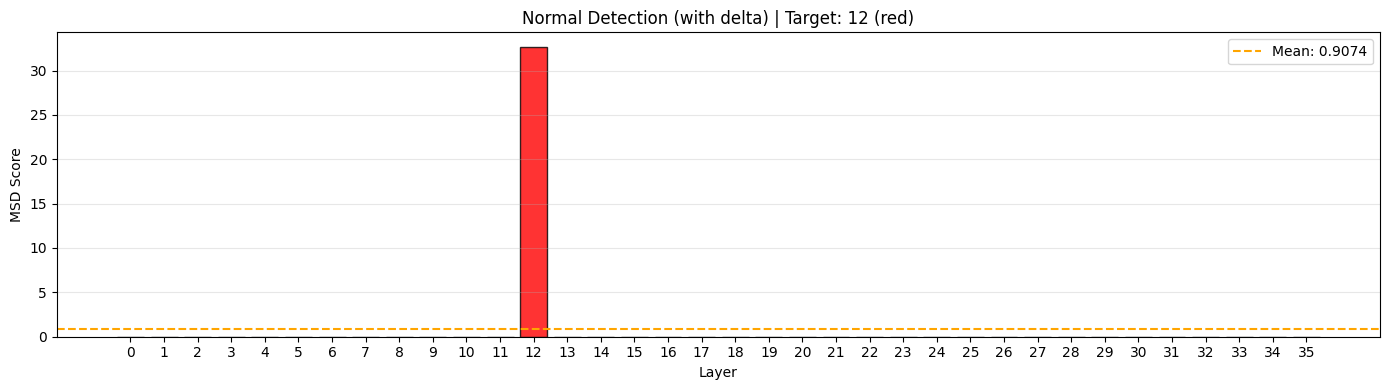

In [38]:
# Normal Detection: All Layer MSD Scores
all_scores = normal.get('all_layer_scores', {})

if all_scores:
    layers = sorted([int(k) for k in all_scores.keys()])
    scores = [all_scores[str(l)] for l in layers]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ['red' if l == target_layer else 'steelblue' for l in layers]
    ax.bar(layers, scores, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=np.mean(scores), color='orange', linestyle='--', label=f'Mean: {np.mean(scores):.4f}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('MSD Score')
    ax.set_title(f'Normal Detection (with delta) | Target: {target_layer} (red)')
    ax.set_xticks(layers)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Normal Detection: Neuron Group Analysis

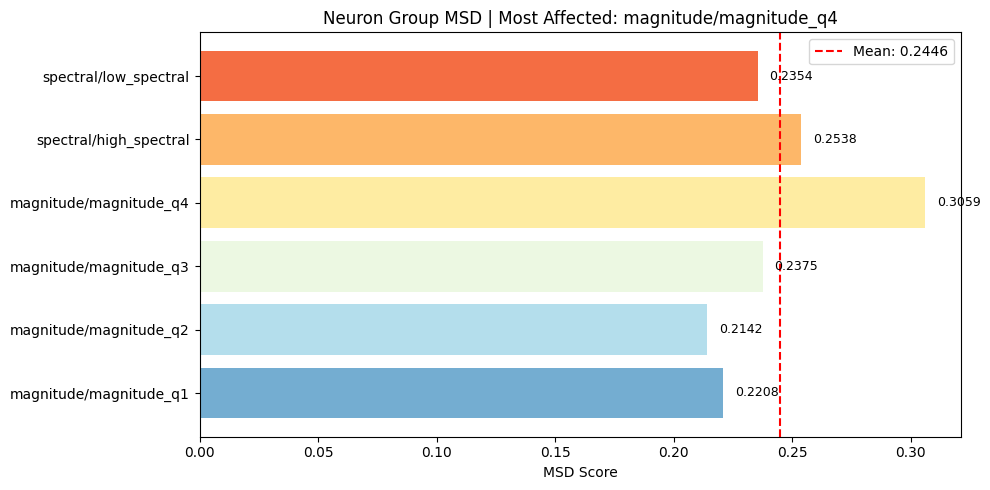

In [39]:
# Neuron Group MSD Breakdown
group_scores = normal.get('group_scores', {})

if group_scores:
    groups = list(group_scores.keys())
    values = list(group_scores.values())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(groups)))
    bars = ax.barh(groups, values, color=colors)
    ax.set_xlabel('MSD Score')
    ax.set_title(f'Neuron Group MSD | Most Affected: {normal.get("most_affected_group", "N/A")}')
    ax.axvline(x=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.4f}')
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Blind Detection: Spectral Features

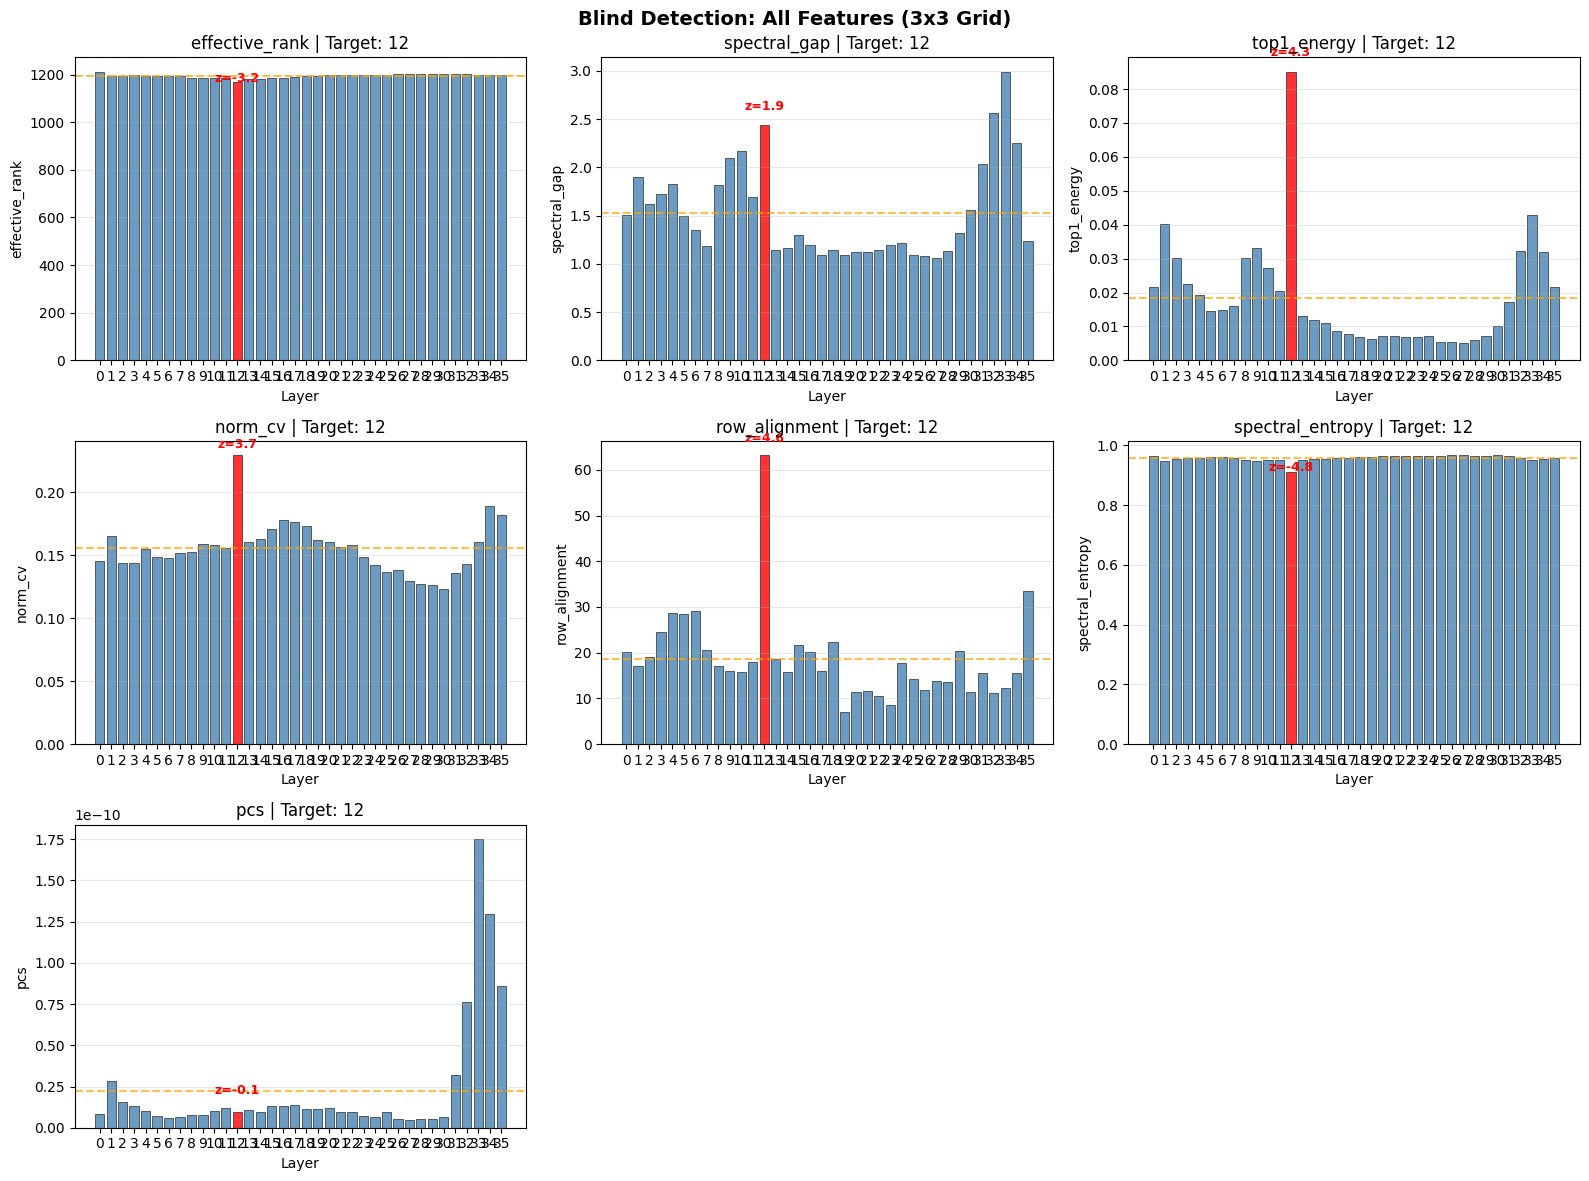

In [40]:
# Blind Detection: ALL Features in 3x3 Grid
# Shows: spectral features (effective_rank, spectral_gap, top1_energy)
#        norm features (norm_cv, row_alignment, spectral_entropy)
#        + pcs if available

layer_features = blind.get('layer_features', {})

if layer_features:
    df = pd.DataFrame.from_dict(layer_features, orient='index')
    df.index = df.index.astype(int)
    df = df.sort_index().replace([np.inf, -np.inf], np.nan)
    
    # All available features in 3x3 grid
    all_metrics = [
        # Row 1: Spectral
        'effective_rank', 'spectral_gap', 'top1_energy',
        # Row 2: Norm/Structure
        'norm_cv', 'row_alignment', 'spectral_entropy',
        # Row 3: More if available
        'pcs', None, None  # pcs is projection cosine similarity
    ]
    
    # Filter to only available metrics
    available = [m for m in all_metrics if m is not None and m in df.columns]
    n_metrics = len(available)
    n_rows = (n_metrics + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, metric in enumerate(available):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
        
        vals = df[metric].values
        layers = df.index.values
        colors = ['red' if l == target_layer else 'steelblue' for l in layers]
        ax.bar(layers, vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(y=np.nanmean(vals), color='orange', linestyle='--', alpha=0.7, label=f'Mean: {np.nanmean(vals):.3f}')
        
        # Z-score annotation for target
        t_idx = list(layers).index(target_layer)
        t_val = vals[t_idx]
        z = (t_val - np.nanmean(vals)) / (np.nanstd(vals) + 1e-10)
        ax.annotate(f'z={z:.1f}', (target_layer, t_val), 
                   xytext=(target_layer, t_val + np.nanstd(vals)*0.3),
                   ha='center', fontweight='bold', color='red', fontsize=9)
        
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} | Target: {target_layer}')
        ax.set_xticks(layers)
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_metrics, n_rows * 3):
        row, col = idx // 3, idx % 3
        axes[row, col].axis('off')
    
    plt.suptitle('Blind Detection: All Features (3x3 Grid)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Blind Detection: Feature Heatmap

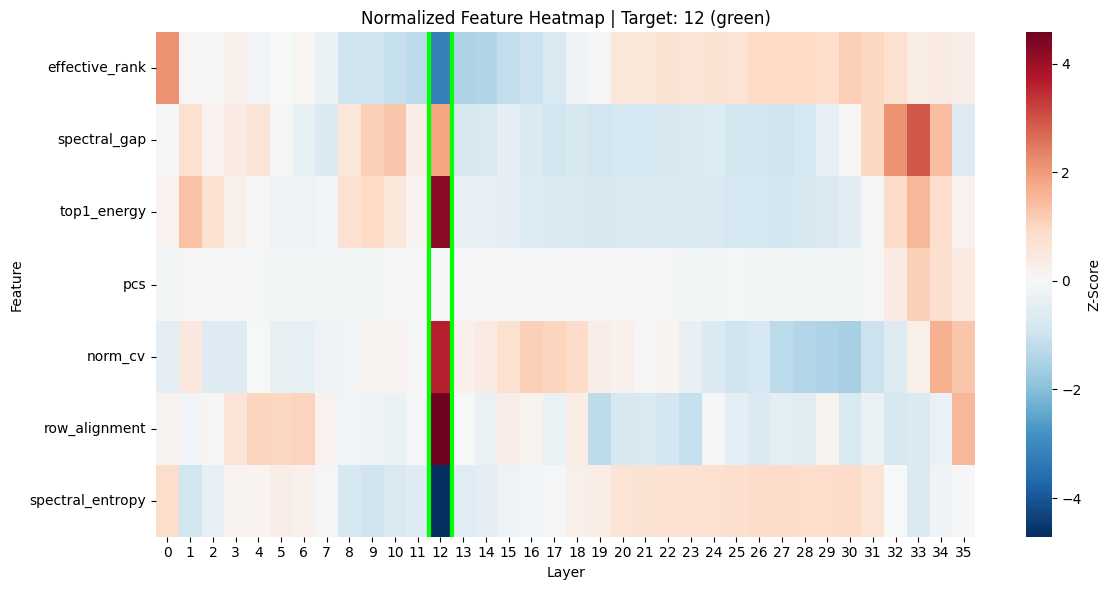

In [41]:
# Feature Heatmap (normalized z-scores)
if layer_features:
    df_norm = (df - df.mean()) / (df.std() + 1e-10)
    df_norm = df_norm.replace([np.inf, -np.inf], np.nan)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(df_norm.T, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'Z-Score'})
    
    # Highlight target layer
    t_idx = list(df_norm.index).index(target_layer)
    ax.axvline(x=t_idx, color='lime', linewidth=3)
    ax.axvline(x=t_idx+1, color='lime', linewidth=3)
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Feature')
    ax.set_title(f'Normalized Feature Heatmap | Target: {target_layer} (green)')
    plt.tight_layout()
    plt.show()

## 6. Blind Grouper Detection

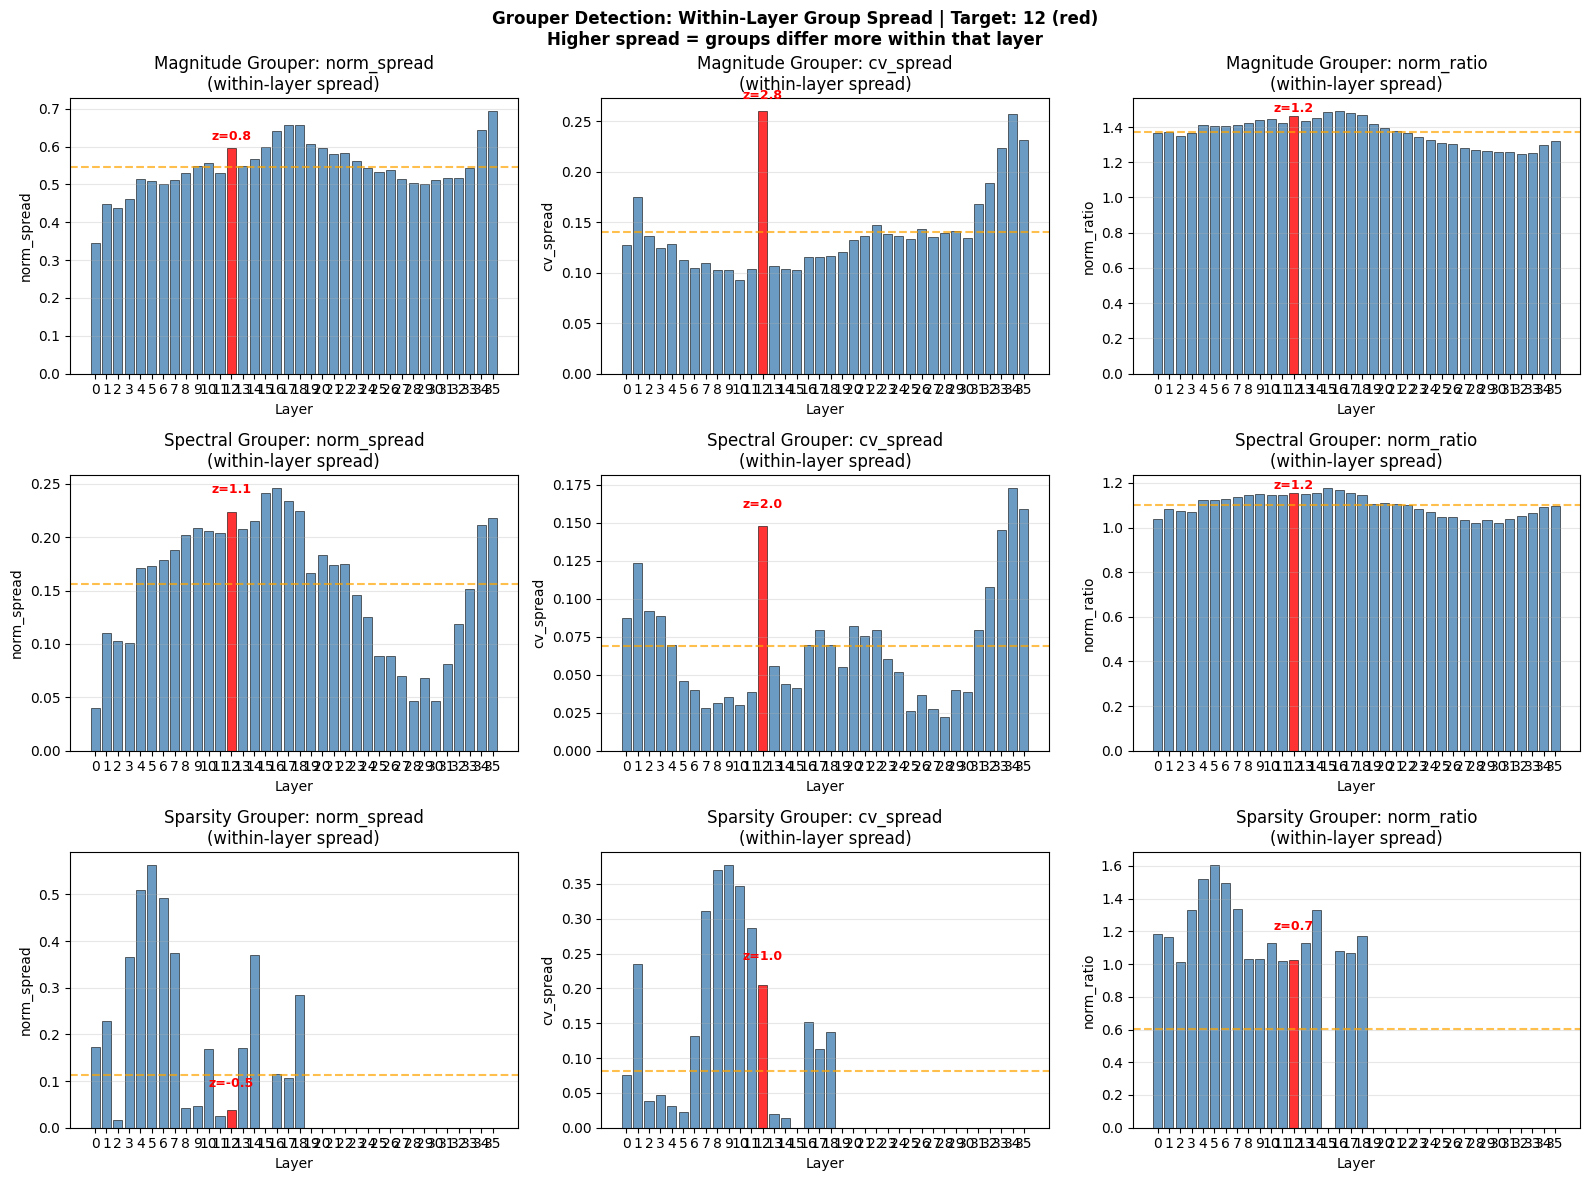

INTERPRETATION:
  Each bar shows how different the neuron groups are WITHIN that layer.
  A SPIKE means one layer has abnormally high within-group differences.
  ROME creates this spike by modifying some neurons but not others.


In [42]:
# Grouper-Based Blind Detection: WITHIN-LAYER Group Comparison
# 
# HOW IT WORKS:
# 1. For each layer, neurons are partitioned into groups (e.g., Q1-Q4 by magnitude)
# 2. For each group, we compute: mean_norm, std_norm, cv_norm
# 3. "Spread" metrics compare BETWEEN groups within the same layer:
#    - norm_spread: how different are group norms (std of group means)
#    - cv_spread: how different are group CVs (std of group CVs)  
#    - norm_ratio: ratio of max/min group norms
#
# If ROME edited a layer, the groups become MORE SPREAD (some neurons changed, others didn't)

grouper_data = blind.get('grouper_detection', {})

if grouper_data and 'layer_group_stats' in grouper_data:
    layer_stats = grouper_data['layer_group_stats']
    layers = sorted([int(k) for k in layer_stats.keys()])
    
    grouper_names = ['magnitude', 'spectral', 'sparsity']
    metrics = ['norm_spread', 'cv_spread', 'norm_ratio']
    
    # Create 3x3 grid: rows = groupers, cols = metrics
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    
    for row, gname in enumerate(grouper_names):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            
            # Get the spread metric for each layer (this compares groups WITHIN that layer)
            vals = []
            for l in layers:
                gdata = layer_stats[str(l)].get(gname, {})
                vals.append(gdata.get(metric, 0))
            
            colors = ['red' if l == target_layer else 'steelblue' for l in layers]
            ax.bar(layers, vals, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
            ax.axhline(y=np.mean(vals), color='orange', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(vals):.3f}')
            
            ax.set_xlabel('Layer')
            ax.set_ylabel(metric)
            ax.set_title(f'{gname.title()} Grouper: {metric}\n(within-layer spread)')
            ax.set_xticks(layers)
            ax.grid(axis='y', alpha=0.3)
            
            # Annotate target layer with z-score
            if target_layer in layers:
                t_idx = layers.index(target_layer)
                t_val = vals[t_idx]
                z = (t_val - np.mean(vals)) / (np.std(vals) + 1e-10)
                ax.annotate(f'z={z:.1f}', (target_layer, t_val), 
                           xytext=(target_layer, t_val + np.std(vals)*0.3),
                           ha='center', fontweight='bold', color='red', fontsize=9)
    
    plt.suptitle(f'Grouper Detection: Within-Layer Group Spread | Target: {target_layer} (red)\n'
                 'Higher spread = groups differ more within that layer', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print explanation
    print("INTERPRETATION:")
    print("  Each bar shows how different the neuron groups are WITHIN that layer.")
    print("  A SPIKE means one layer has abnormally high within-group differences.")
    print("  ROME creates this spike by modifying some neurons but not others.")
else:
    print("No grouper detection data")

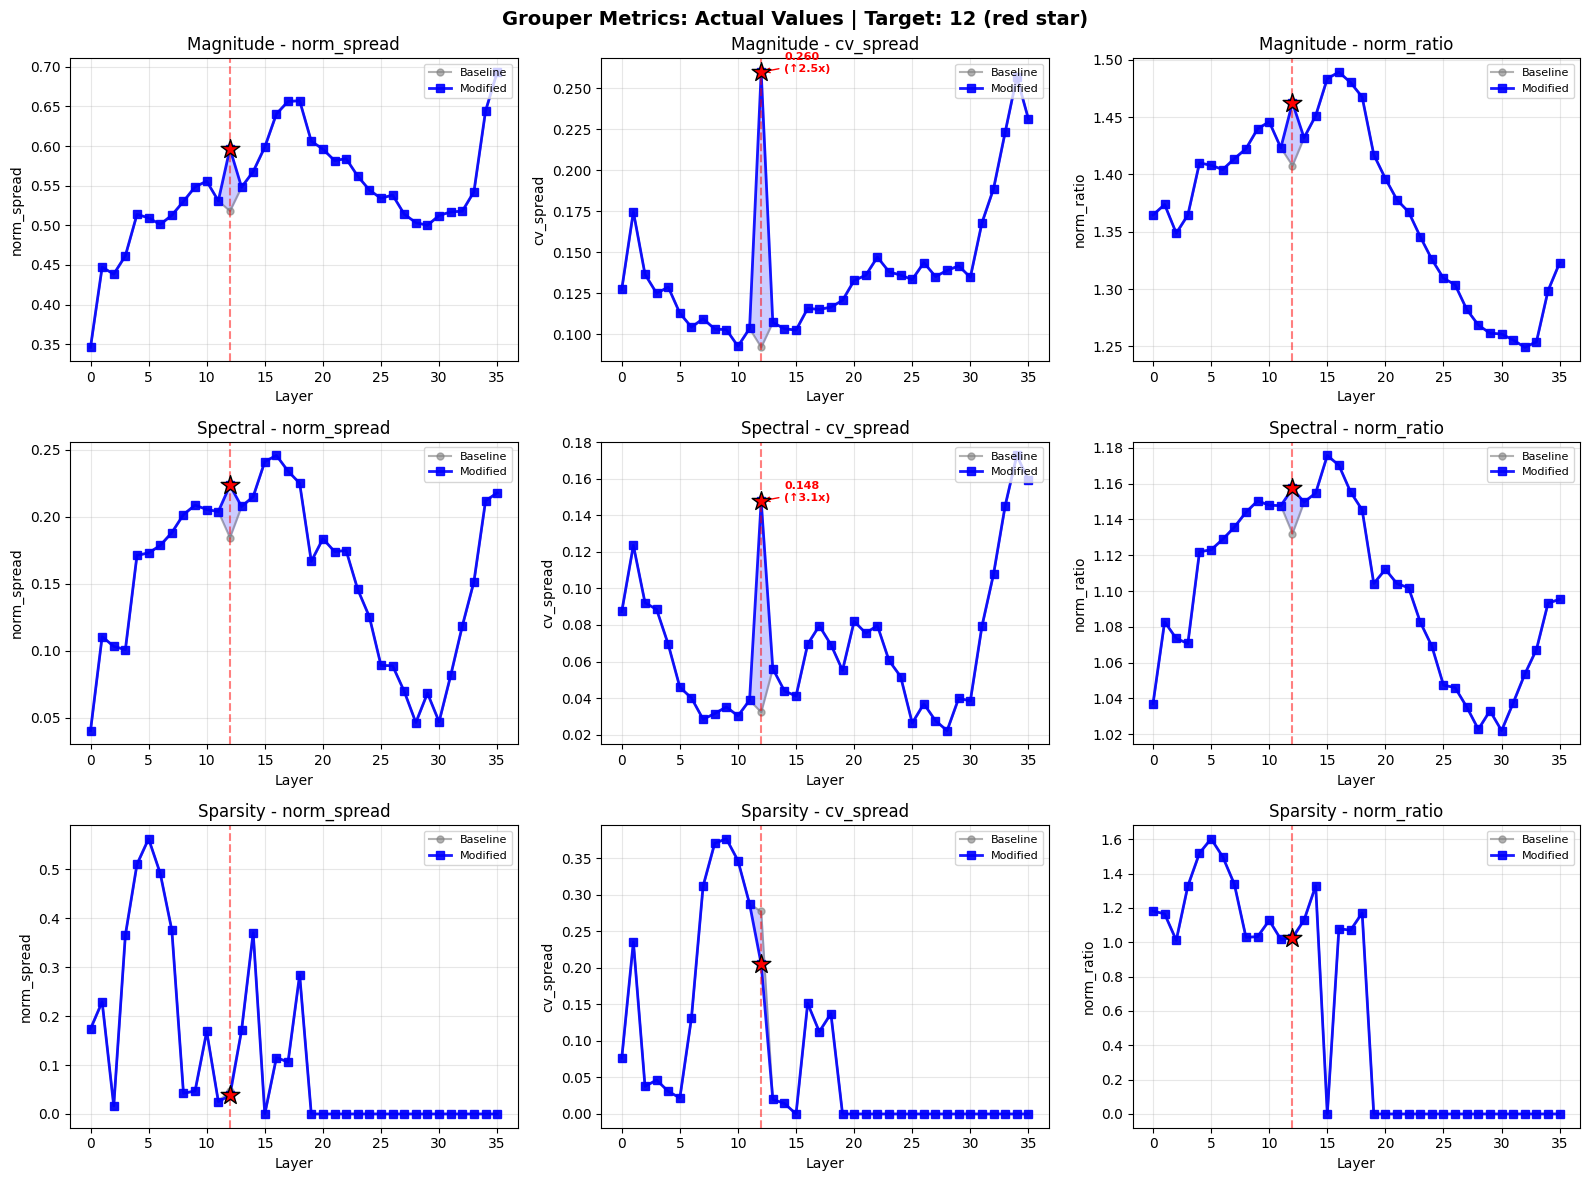


=== SPIKE DETECTION: How much does target layer stand out? ===
Metric                        Target    Neighbors    Ratio
----------------------------------------------------------
spectral/cv_spread            0.1478       0.0475    3.11x SPIKE!
magnitude/cv_spread           0.2599       0.1053    2.47x SPIKE!
sparsity/norm_spread          0.0378       0.0981    0.39x SPIKE!
sparsity/cv_spread            0.2050       0.1536    1.33x 
magnitude/norm_spread         0.5968       0.5395    1.11x 
spectral/norm_spread          0.2234       0.2057    1.09x 


In [43]:
# Grouper Detection: See the SPIKE at the edited layer
# Shows ACTUAL VALUES so you can see how layer 12 is inconsistent with others

grouper_data = blind.get('grouper_detection', {})
baseline_grouper = data.get('baseline_blind', {}).get('grouper_detection', {})

if grouper_data and baseline_grouper and 'layer_group_stats' in grouper_data:
    mod_stats = grouper_data['layer_group_stats']
    base_stats = baseline_grouper['layer_group_stats']
    layers = sorted([int(k) for k in mod_stats.keys()])
    
    grouper_names = ['magnitude', 'spectral', 'sparsity']
    metrics = ['norm_spread', 'cv_spread', 'norm_ratio']
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    
    for row, gname in enumerate(grouper_names):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            
            # Get ACTUAL VALUES for baseline and modified
            base_vals = [base_stats[str(l)].get(gname, {}).get(metric, 0) for l in layers]
            mod_vals = [mod_stats[str(l)].get(gname, {}).get(metric, 0) for l in layers]
            
            # Plot both lines
            ax.plot(layers, base_vals, 'o-', color='gray', alpha=0.6, label='Baseline', markersize=5)
            ax.plot(layers, mod_vals, 's-', color='blue', alpha=0.9, label='Modified', markersize=6, linewidth=2)
            
            # Highlight the target layer with a big red marker
            t_idx = layers.index(target_layer)
            ax.scatter([target_layer], [mod_vals[t_idx]], s=200, color='red', zorder=10, marker='*', edgecolor='black')
            
            # Shade the region between baseline and modified
            ax.fill_between(layers, base_vals, mod_vals, alpha=0.2, color='blue')
            
            # Add vertical line at target
            ax.axvline(target_layer, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
            
            ax.set_xlabel('Layer')
            ax.set_ylabel(metric)
            ax.set_title(f'{gname.title()} - {metric}')
            ax.legend(fontsize=8, loc='upper right')
            ax.grid(alpha=0.3)
            
            # Annotate the spike value at target layer
            mod_val = mod_vals[t_idx]
            neighbors = [mod_vals[t_idx-1], mod_vals[t_idx+1]] if 0 < t_idx < len(mod_vals)-1 else []
            if neighbors:
                neighbor_avg = np.mean(neighbors)
                if mod_val > neighbor_avg * 1.5:  # Significant spike
                    ax.annotate(f'{mod_val:.3f}\n(↑{mod_val/neighbor_avg:.1f}x)', 
                               (target_layer, mod_val), xytext=(target_layer+2, mod_val),
                               fontsize=8, color='red', fontweight='bold',
                               arrowprops=dict(arrowstyle='->', color='red', lw=1))
    
    plt.suptitle(f'Grouper Metrics: Actual Values | Target: {target_layer} (red star)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary: which metrics show the biggest JUMP at target
    print("\n=== SPIKE DETECTION: How much does target layer stand out? ===")
    spikes = []
    for gname in grouper_names:
        for metric in metrics:
            mod_vals = [mod_stats[str(l)].get(gname, {}).get(metric, 0) for l in layers]
            t_idx = layers.index(target_layer)
            t_val = mod_vals[t_idx]
            # Compare to neighbors
            neighbors = []
            if t_idx > 0: neighbors.append(mod_vals[t_idx-1])
            if t_idx < len(mod_vals)-1: neighbors.append(mod_vals[t_idx+1])
            neighbor_avg = np.mean(neighbors) if neighbors else 0
            ratio = t_val / neighbor_avg if neighbor_avg > 0 else 0
            spikes.append((f'{gname}/{metric}', t_val, neighbor_avg, ratio))
    
    spikes.sort(key=lambda x: abs(x[3] - 1), reverse=True)  # Sort by how much it deviates from 1.0
    print(f"{'Metric':<25} {'Target':>10} {'Neighbors':>12} {'Ratio':>8}")
    print("-" * 58)
    for name, t_val, n_avg, ratio in spikes[:6]:
        flag = "SPIKE!" if ratio > 1.5 or ratio < 0.5 else ""
        print(f"{name:<25} {t_val:>10.4f} {n_avg:>12.4f} {ratio:>7.2f}x {flag}")
else:
    print("No grouper data available")

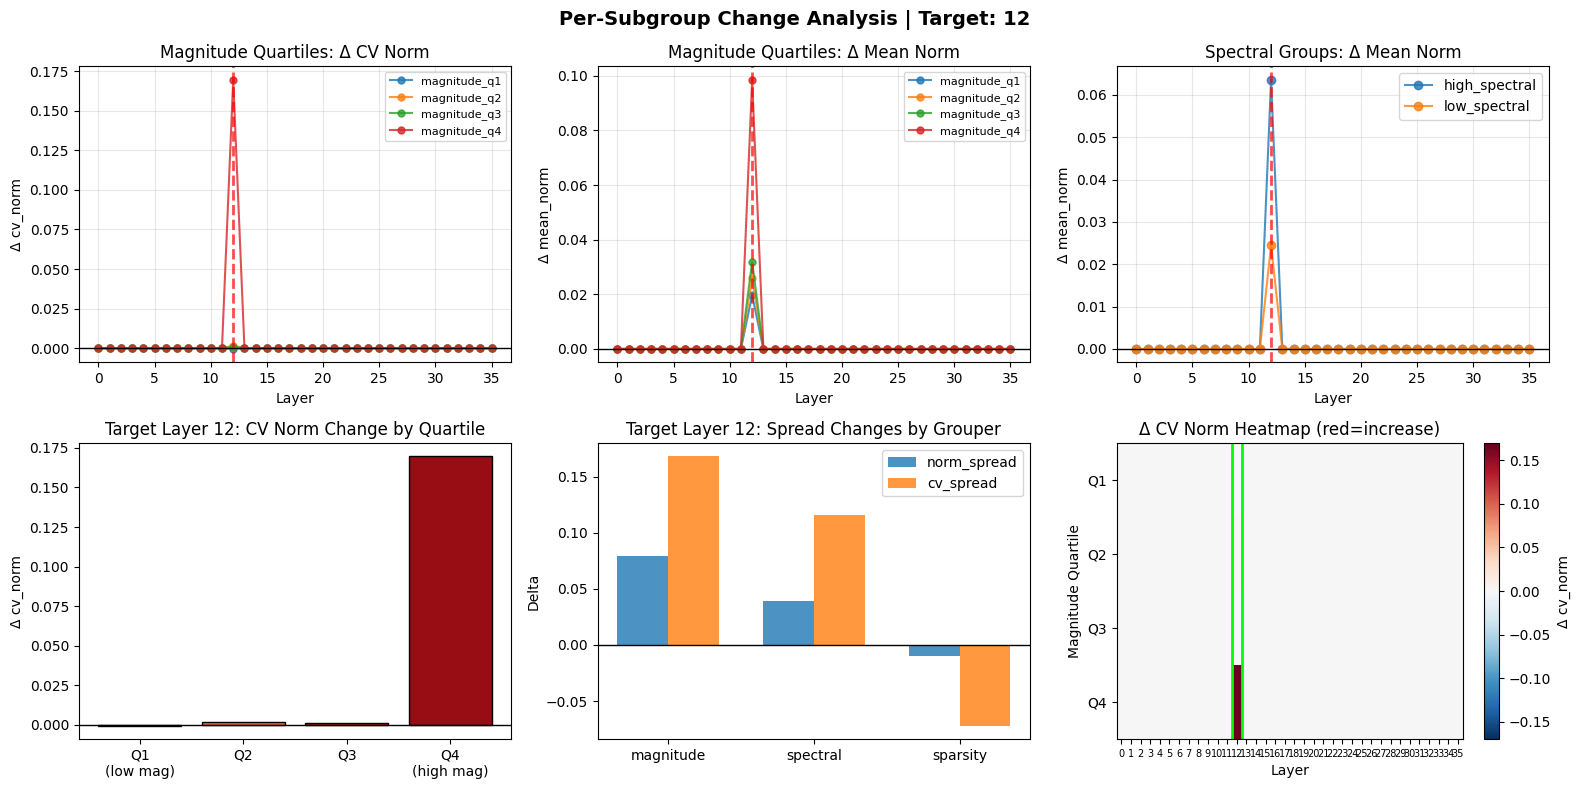


=== KEY FINDING ===
At target layer 12:
  Q4 (high-magnitude neurons) cv_norm change: +0.1696
  Q1 (low-magnitude neurons) cv_norm change: -0.0005
  -> ROME primarily affects HIGH-MAGNITUDE neurons (Q4)


In [44]:
# Per-Subgroup Change Analysis: Which neuron groups are most affected?
# Grouping works by partitioning neurons based on their properties:
# - magnitude_q1-q4: quartiles by row norm (q4 = highest magnitude neurons)
# - high/low_spectral: neurons aligned vs not aligned with top singular vector
# - dense/medium/sparse: by sparsity pattern

if grouper_data and baseline_grouper and 'layer_group_stats' in grouper_data:
    mod_stats = grouper_data['layer_group_stats']
    base_stats = baseline_grouper['layer_group_stats']
    layers = sorted([int(k) for k in mod_stats.keys()])
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    
    # ===== Row 1: Per-quartile cv_norm DELTA =====
    ax = axes[0, 0]
    for q in ['magnitude_q1', 'magnitude_q2', 'magnitude_q3', 'magnitude_q4']:
        deltas = []
        for l in layers:
            mod_val = mod_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
            base_val = base_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
            deltas.append(mod_val - base_val)
        ax.plot(layers, deltas, 'o-', label=q, alpha=0.8, markersize=5)
    ax.axvline(target_layer, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Δ cv_norm')
    ax.set_title('Magnitude Quartiles: Δ CV Norm')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # ===== Row 1: Per-quartile mean_norm DELTA =====
    ax = axes[0, 1]
    for q in ['magnitude_q1', 'magnitude_q2', 'magnitude_q3', 'magnitude_q4']:
        deltas = []
        for l in layers:
            mod_val = mod_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('mean_norm', 0)
            base_val = base_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('mean_norm', 0)
            deltas.append(mod_val - base_val)
        ax.plot(layers, deltas, 'o-', label=q, alpha=0.8, markersize=5)
    ax.axvline(target_layer, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Δ mean_norm')
    ax.set_title('Magnitude Quartiles: Δ Mean Norm')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    # ===== Row 1: Spectral groups DELTA =====
    ax = axes[0, 2]
    for g in ['high_spectral', 'low_spectral']:
        deltas = []
        for l in layers:
            mod_val = mod_stats[str(l)].get('spectral', {}).get('groups', {}).get(g, {}).get('mean_norm', 0)
            base_val = base_stats[str(l)].get('spectral', {}).get('groups', {}).get(g, {}).get('mean_norm', 0)
            deltas.append(mod_val - base_val)
        ax.plot(layers, deltas, 'o-', label=g, alpha=0.8, markersize=6)
    ax.axvline(target_layer, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Δ mean_norm')
    ax.set_title('Spectral Groups: Δ Mean Norm')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # ===== Row 2: Bar chart of TARGET LAYER changes by subgroup =====
    ax = axes[1, 0]
    subgroups = ['magnitude_q1', 'magnitude_q2', 'magnitude_q3', 'magnitude_q4']
    target_deltas = []
    for q in subgroups:
        mod_val = mod_stats[str(target_layer)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
        base_val = base_stats[str(target_layer)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
        target_deltas.append(mod_val - base_val)
    
    colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(subgroups)))
    ax.bar(range(len(subgroups)), target_deltas, color=colors, edgecolor='black')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel('Δ cv_norm')
    ax.set_title(f'Target Layer {target_layer}: CV Norm Change by Quartile')
    ax.set_xticks(range(len(subgroups)))
    ax.set_xticklabels(['Q1\n(low mag)', 'Q2', 'Q3', 'Q4\n(high mag)'])
    
    # ===== Row 2: Compare all grouper spreads at target =====
    ax = axes[1, 1]
    groupers = ['magnitude', 'spectral', 'sparsity']
    metrics = ['norm_spread', 'cv_spread']
    x = np.arange(len(groupers))
    width = 0.35
    
    for i, metric in enumerate(metrics):
        deltas = []
        for gname in groupers:
            mod_val = mod_stats[str(target_layer)].get(gname, {}).get(metric, 0)
            base_val = base_stats[str(target_layer)].get(gname, {}).get(metric, 0)
            deltas.append(mod_val - base_val)
        ax.bar(x + i*width - width/2, deltas, width, label=metric, alpha=0.8)
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(groupers)
    ax.set_ylabel('Delta')
    ax.set_title(f'Target Layer {target_layer}: Spread Changes by Grouper')
    ax.legend()
    
    # ===== Row 2: Heatmap of all changes =====
    ax = axes[1, 2]
    # Build matrix: rows = layers, cols = subgroup metrics
    heatmap_data = []
    for l in layers:
        row = []
        for q in ['magnitude_q1', 'magnitude_q2', 'magnitude_q3', 'magnitude_q4']:
            mod_val = mod_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
            base_val = base_stats[str(l)].get('magnitude', {}).get('groups', {}).get(q, {}).get('cv_norm', 0)
            row.append(mod_val - base_val)
        heatmap_data.append(row)
    
    heatmap_arr = np.array(heatmap_data)
    vmax = np.abs(heatmap_arr).max()
    im = ax.imshow(heatmap_arr.T, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(layers)))
    ax.set_xticklabels(layers, fontsize=7)
    ax.set_yticks(range(4))
    ax.set_yticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.set_xlabel('Layer')
    ax.set_ylabel('Magnitude Quartile')
    ax.set_title('Δ CV Norm Heatmap (red=increase)')
    plt.colorbar(im, ax=ax, label='Δ cv_norm')
    
    # Highlight target layer
    ax.axvline(layers.index(target_layer) - 0.5, color='lime', linewidth=2)
    ax.axvline(layers.index(target_layer) + 0.5, color='lime', linewidth=2)
    
    plt.suptitle(f'Per-Subgroup Change Analysis | Target: {target_layer}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Key finding
    print("\n=== KEY FINDING ===")
    q4_delta = target_deltas[3]  # Q4 change
    q1_delta = target_deltas[0]  # Q1 change
    print(f"At target layer {target_layer}:")
    print(f"  Q4 (high-magnitude neurons) cv_norm change: {q4_delta:+.4f}")
    print(f"  Q1 (low-magnitude neurons) cv_norm change: {q1_delta:+.4f}")
    if abs(q4_delta) > abs(q1_delta) * 2:
        print(f"  -> ROME primarily affects HIGH-MAGNITUDE neurons (Q4)")
    else:
        print(f"  -> Change is distributed across quartiles")

## 7. Baseline vs Modified Comparison

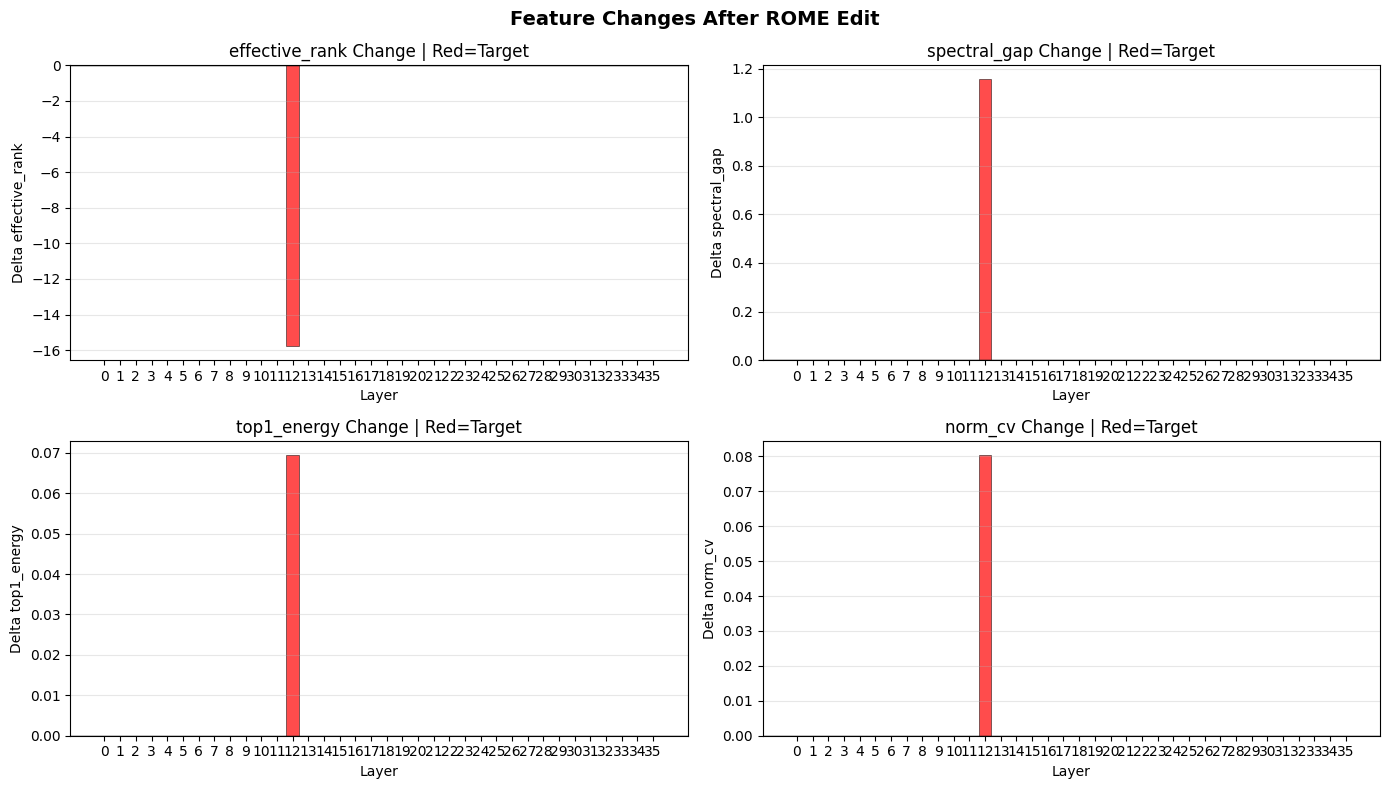

In [45]:
# Baseline vs Modified Feature Comparison
baseline_blind = data.get('baseline_blind', {})
baseline_features = baseline_blind.get('layer_features', {})

if baseline_features and layer_features:
    df_base = pd.DataFrame.from_dict(baseline_features, orient='index')
    df_base.index = df_base.index.astype(int)
    df_base = df_base.sort_index().replace([np.inf, -np.inf], np.nan)
    
    df_diff = df - df_base
    
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    for ax, metric in zip(axes.flatten(), metrics):
        vals = df_diff[metric].values
        layers = df_diff.index.values
        colors = ['red' if l == target_layer else ('green' if v > 0 else 'blue') for l, v in zip(layers, vals)]
        ax.bar(layers, vals, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='black', linewidth=1)
        ax.set_xlabel('Layer')
        ax.set_ylabel(f'Delta {metric}')
        ax.set_title(f'{metric} Change | Red=Target')
        ax.set_xticks(layers)
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Feature Changes After ROME Edit', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Singular Value Analysis

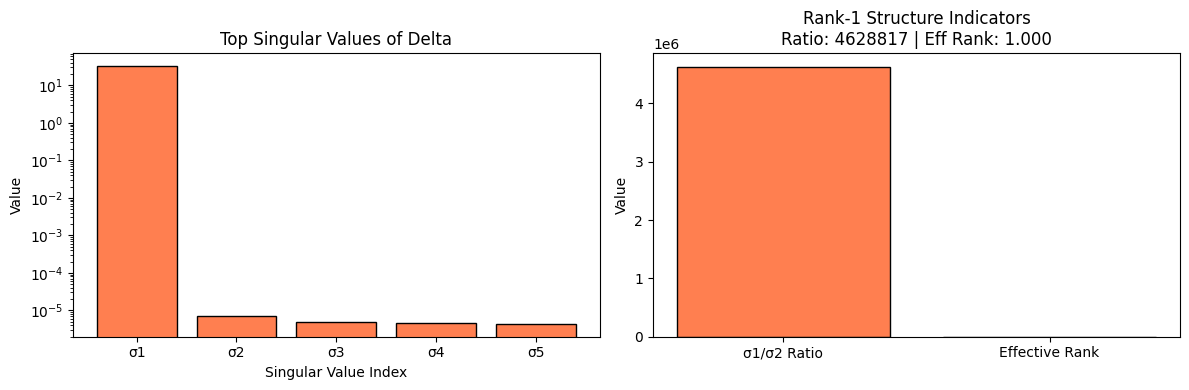

In [46]:
# Singular Value Analysis
svs = normal.get('top_singular_values', [])

if svs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Bar chart of top SVs
    ax = axes[0]
    ax.bar(range(len(svs)), svs, color='coral', edgecolor='black')
    ax.set_xlabel('Singular Value Index')
    ax.set_ylabel('Value')
    ax.set_title(f'Top Singular Values of Delta')
    ax.set_yscale('log')
    ax.set_xticks(range(len(svs)))
    ax.set_xticklabels([f'σ{i+1}' for i in range(len(svs))])
    
    # Ratio
    ax = axes[1]
    ratio = svs[0] / (svs[1] + 1e-10) if len(svs) >= 2 else 0
    eff_rank = normal.get('effective_rank', 0)
    ax.bar(['σ1/σ2 Ratio', 'Effective Rank'], [ratio, eff_rank], color=['coral', 'teal'], edgecolor='black')
    ax.set_ylabel('Value')
    ax.set_title(f'Rank-1 Structure Indicators\nRatio: {ratio:.0f} | Eff Rank: {eff_rank:.3f}')
    
    plt.tight_layout()
    plt.show()

## 9. Interlayer Analysis

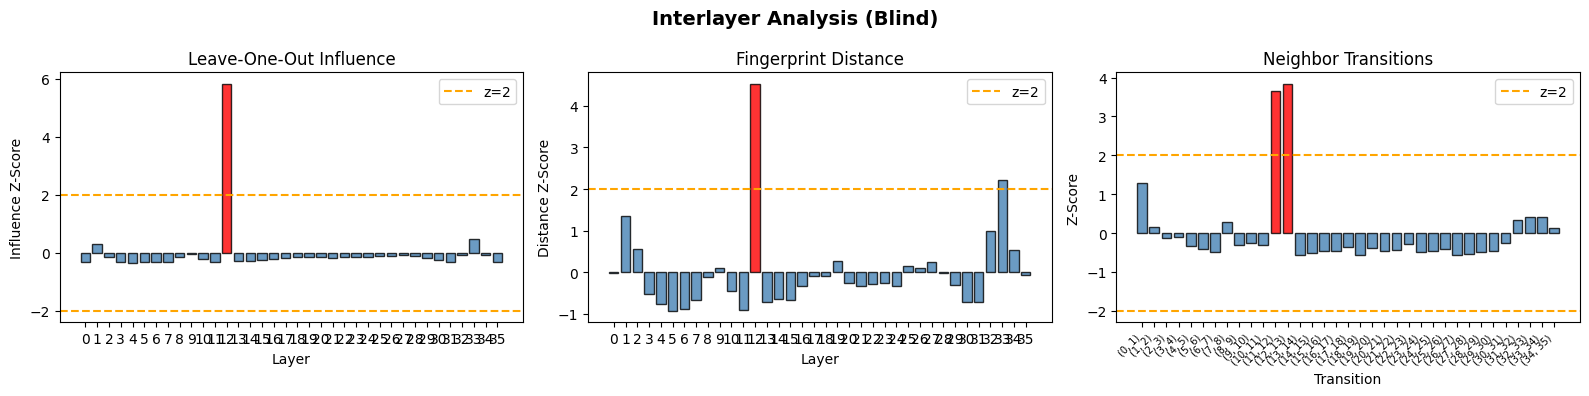

In [47]:
# Interlayer Analysis: Key Z-Scores
interlayer = case.get('interlayer', {})

if interlayer:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Leave-One-Out Influence
    ax = axes[0]
    loo = interlayer.get('leave_one_out', {})
    inf_z = loo.get('influence_z_scores', {})
    if inf_z:
        layers = sorted([int(k) for k in inf_z.keys()])
        vals = [inf_z[str(l)] for l in layers]
        colors = ['red' if l == target_layer else 'steelblue' for l in layers]
        ax.bar(layers, vals, color=colors, alpha=0.8, edgecolor='black')
        ax.axhline(2, color='orange', linestyle='--', label='z=2')
        ax.axhline(-2, color='orange', linestyle='--')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Influence Z-Score')
        ax.set_title('Leave-One-Out Influence')
        ax.set_xticks(layers)
        ax.legend()
    
    # 2. Fingerprint Distance
    ax = axes[1]
    fp = interlayer.get('fingerprint', {})
    dist_z = fp.get('distance_z_scores', {})
    if dist_z:
        layers = sorted([int(k) for k in dist_z.keys()])
        vals = [dist_z[str(l)] for l in layers]
        colors = ['red' if l == target_layer else 'steelblue' for l in layers]
        ax.bar(layers, vals, color=colors, alpha=0.8, edgecolor='black')
        ax.axhline(2, color='orange', linestyle='--', label='z=2')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Distance Z-Score')
        ax.set_title('Fingerprint Distance')
        ax.set_xticks(layers)
        ax.legend()
    
    # 3. Neighbor Transitions
    ax = axes[2]
    trans = interlayer.get('neighbor_transitions', {})
    trans_z = trans.get('transition_z_scores', {})
    if trans_z:
        pairs = list(trans_z.keys())
        vals = list(trans_z.values())
        colors = ['red' if str(target_layer) in str(p) else 'steelblue' for p in pairs]
        ax.bar(range(len(pairs)), vals, color=colors, alpha=0.8, edgecolor='black')
        ax.axhline(2, color='orange', linestyle='--', label='z=2')
        ax.axhline(-2, color='orange', linestyle='--')
        ax.set_xlabel('Transition')
        ax.set_ylabel('Z-Score')
        ax.set_title('Neighbor Transitions')
        ax.set_xticks(range(len(pairs)))
        ax.set_xticklabels([str(p) for p in pairs], rotation=45, ha='right', fontsize=7)
        ax.legend()
    
    plt.suptitle('Interlayer Analysis (Blind)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No interlayer data")

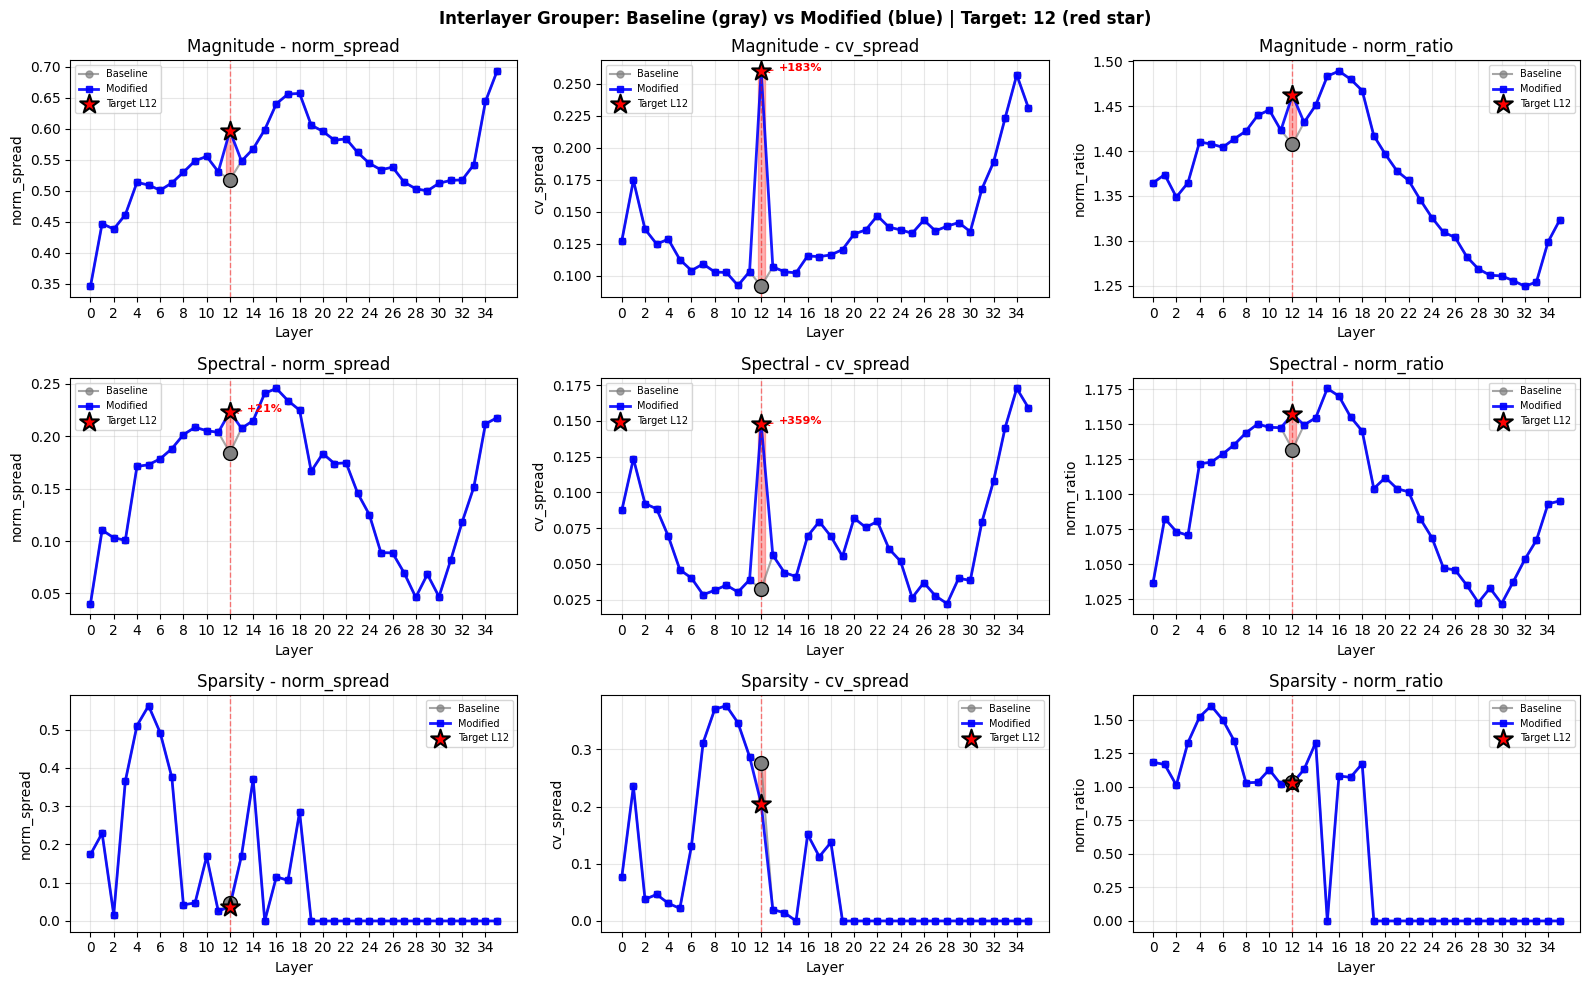


=== INTERLAYER GROUPER: BASELINE vs MODIFIED at Target Layer ===
Grouper      Metric            Baseline   Modified     Change    %Change
----------------------------------------------------------------------
magnitude    norm_spread         0.5180     0.5968    +0.0788     +15.2% 
magnitude    cv_spread           0.0920     0.2599    +0.1680    +182.7% ***
magnitude    norm_ratio          1.4076     1.4625    +0.0549      +3.9% 
spectral     norm_spread         0.1844     0.2234    +0.0390     +21.2% 
spectral     cv_spread           0.0322     0.1478    +0.1156    +358.6% ***
spectral     norm_ratio          1.1321     1.1573    +0.0252      +2.2% 
sparsity     norm_spread         0.0478     0.0378    -0.0101     -21.0% 
sparsity     cv_spread           0.2769     0.2050    -0.0719     -26.0% 
sparsity     norm_ratio          1.0332     1.0246    -0.0086      -0.8% 


In [51]:
# Interlayer Grouper: BASELINE vs MODIFIED Side-by-Side
# Shows the ACTUAL cv_spread values for each layer, not computed deltas

grouper_data = blind.get('grouper_detection', {})
baseline_grouper = data.get('baseline_blind', {}).get('grouper_detection', {})

if grouper_data and baseline_grouper and 'layer_group_stats' in grouper_data:
    mod_stats = grouper_data['layer_group_stats']
    base_stats = baseline_grouper['layer_group_stats']
    layers = sorted([int(k) for k in mod_stats.keys()])
    
    grouper_names = ['magnitude', 'spectral', 'sparsity']
    
    # Create 3x3 grid: rows = groupers, cols = metrics
    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    metrics = ['norm_spread', 'cv_spread', 'norm_ratio']
    
    for row, gname in enumerate(grouper_names):
        for col, metric in enumerate(metrics):
            ax = axes[row, col]
            
            # Get ACTUAL values for both baseline and modified
            base_vals = [base_stats[str(l)].get(gname, {}).get(metric, 0) for l in layers]
            mod_vals = [mod_stats[str(l)].get(gname, {}).get(metric, 0) for l in layers]
            
            # Plot both lines
            ax.plot(layers, base_vals, 'o-', color='gray', alpha=0.7, label='Baseline', markersize=5, linewidth=1.5)
            ax.plot(layers, mod_vals, 's-', color='blue', alpha=0.9, label='Modified', markersize=5, linewidth=2)
            
            # Highlight target layer
            t_idx = layers.index(target_layer)
            ax.scatter([target_layer], [mod_vals[t_idx]], s=200, color='red', zorder=10, marker='*', 
                      edgecolor='black', linewidth=1.5, label=f'Target L{target_layer}')
            ax.scatter([target_layer], [base_vals[t_idx]], s=100, color='gray', zorder=9, marker='o', 
                      edgecolor='black', linewidth=1)
            
            # Shade difference at target
            ax.fill_between([target_layer-0.3, target_layer+0.3], 
                           [base_vals[t_idx], base_vals[t_idx]], 
                           [mod_vals[t_idx], mod_vals[t_idx]], 
                           color='red', alpha=0.3)
            
            ax.axvline(target_layer, color='red', linestyle='--', linewidth=1, alpha=0.5)
            
            ax.set_xlabel('Layer')
            ax.set_ylabel(metric)
            ax.set_title(f'{gname.title()} - {metric}')
            ax.legend(fontsize=7, loc='best')
            ax.grid(alpha=0.3)
            ax.set_xticks(layers[::2])  # Show every other layer for readability
            
            # Annotate the jump at target
            base_v = base_vals[t_idx]
            mod_v = mod_vals[t_idx]
            if mod_v > base_v * 1.2:  # >20% increase
                ax.annotate(f'+{(mod_v/base_v - 1)*100:.0f}%', 
                           (target_layer, mod_v), xytext=(target_layer + 1.5, mod_v),
                           fontsize=8, color='red', fontweight='bold',
                           arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    
    plt.suptitle(f'Interlayer Grouper: Baseline (gray) vs Modified (blue) | Target: {target_layer} (red star)', 
                fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n=== INTERLAYER GROUPER: BASELINE vs MODIFIED at Target Layer ===")
    print(f"{'Grouper':<12} {'Metric':<15} {'Baseline':>10} {'Modified':>10} {'Change':>10} {'%Change':>10}")
    print("-" * 70)
    for gname in grouper_names:
        for metric in metrics:
            base_v = base_stats[str(target_layer)].get(gname, {}).get(metric, 0)
            mod_v = mod_stats[str(target_layer)].get(gname, {}).get(metric, 0)
            delta = mod_v - base_v
            pct = (delta / base_v * 100) if base_v > 0 else 0
            flag = "***" if abs(pct) > 50 else ""
            print(f"{gname:<12} {metric:<15} {base_v:>10.4f} {mod_v:>10.4f} {delta:>+10.4f} {pct:>+9.1f}% {flag}")
else:
    print("No grouper data available")

## 10. Cross-Case Summary

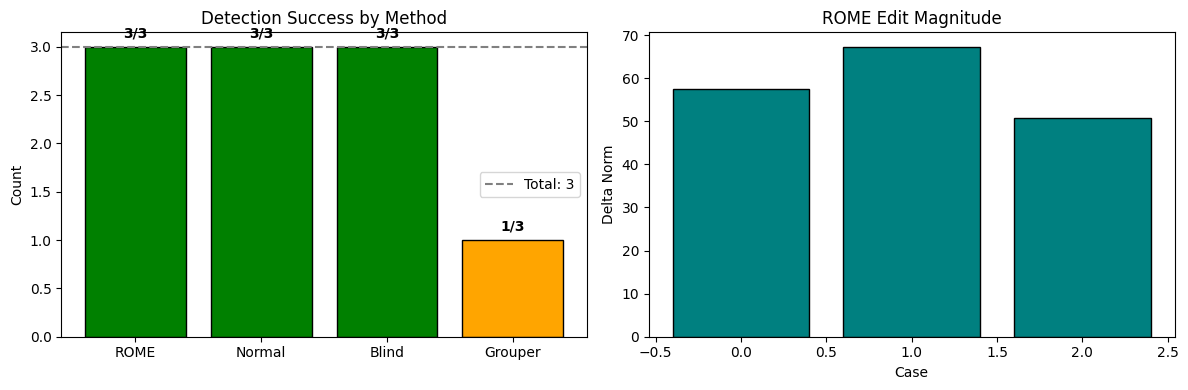


Summary: 3/3 normal, 3/3 blind, 1/3 grouper correct


In [49]:
# Cross-Case Detection Summary
rows = []
for t in data['tests']:
    if t.get('error'):
        continue
    n = t.get('normal_detection', {})
    b = t.get('blind_detection', {})
    g = b.get('grouper_detection', {})
    
    rows.append({
        'case': t['case_id'],
        'subject': t['subject'][:20],
        'rome_ok': t.get('rome', {}).get('success', False),
        'normal_ok': n.get('anomalous_layer') == target_layer,
        'blind_ok': b.get('anomalous_layer') == target_layer,
        'grouper_ok': g.get('anomalous_layer') == target_layer,
        'delta_norm': t.get('rome', {}).get('delta_norm', 0),
    })

df_summary = pd.DataFrame(rows)

if len(df_summary) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Detection accuracy
    ax = axes[0]
    methods = ['rome_ok', 'normal_ok', 'blind_ok', 'grouper_ok']
    labels = ['ROME', 'Normal', 'Blind', 'Grouper']
    counts = [df_summary[m].sum() for m in methods]
    colors = ['green' if c == len(df_summary) else 'orange' if c > 0 else 'red' for c in counts]
    ax.bar(labels, counts, color=colors, edgecolor='black')
    ax.axhline(len(df_summary), color='gray', linestyle='--', label=f'Total: {len(df_summary)}')
    ax.set_ylabel('Count')
    ax.set_title('Detection Success by Method')
    ax.legend()
    for i, c in enumerate(counts):
        ax.text(i, c + 0.1, f'{c}/{len(df_summary)}', ha='center', fontweight='bold')
    
    # Delta norms
    ax = axes[1]
    ax.bar(df_summary['case'], df_summary['delta_norm'], color='teal', edgecolor='black')
    ax.set_xlabel('Case')
    ax.set_ylabel('Delta Norm')
    ax.set_title('ROME Edit Magnitude')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSummary: {df_summary['normal_ok'].sum()}/{len(df_summary)} normal, "
          f"{df_summary['blind_ok'].sum()}/{len(df_summary)} blind, "
          f"{df_summary['grouper_ok'].sum()}/{len(df_summary)} grouper correct")

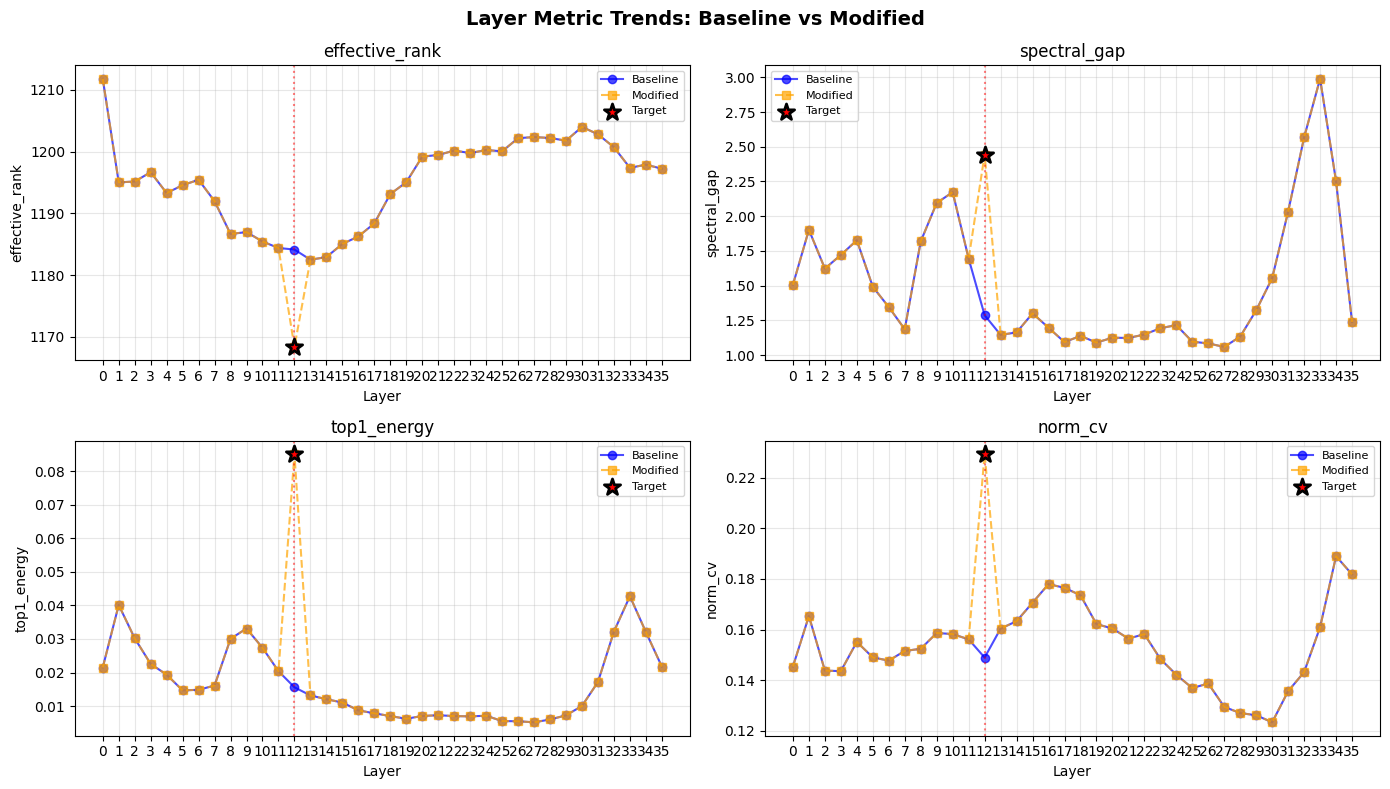

In [50]:
# Layer Metric Trends: Baseline vs Modified
if baseline_features and layer_features:
    metrics = ['effective_rank', 'spectral_gap', 'top1_energy', 'norm_cv']
    layers = sorted(df.index.tolist())
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    for ax, metric in zip(axes.flatten(), metrics):
        base_vals = [df_base.loc[l, metric] if l in df_base.index else np.nan for l in layers]
        mod_vals = [df.loc[l, metric] if l in df.index else np.nan for l in layers]
        
        ax.plot(layers, base_vals, 'o-', label='Baseline', color='blue', alpha=0.7)
        ax.plot(layers, mod_vals, 's--', label='Modified', color='orange', alpha=0.7)
        
        if target_layer in layers:
            t_idx = layers.index(target_layer)
            ax.scatter([target_layer], [mod_vals[t_idx]], color='red', s=150, marker='*', 
                      edgecolor='black', linewidth=2, zorder=5, label='Target')
        
        ax.axvline(x=target_layer, color='red', linestyle=':', alpha=0.5)
        ax.set_xlabel('Layer')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend(loc='best', fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xticks(layers)
    
    plt.suptitle('Layer Metric Trends: Baseline vs Modified', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()